# StoryZop: Instagram Story Visual Analysis

This notebook runs the complete StoryZop pipeline on Google Colab.

**Before running:**
1. Change runtime to **GPU** (Runtime → Change runtime type → T4 GPU)
2. Export your Instagram cookies locally:
   ```bash
   pip install browser-cookie3
   python extract_cookies.py
   ```
3. Upload `data/session.json` to this Colab notebook (use the file upload in Cell 6)

## 1. Install Dependencies & Clone Repo

In [1]:
# Core dependencies
!pip install -q playwright Pillow pydantic pydantic-settings python-dotenv nest-asyncio

# Install Chromium WITH system dependencies (critical for Colab)
!playwright install --with-deps chromium

# AI / Vision dependencies
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -q transformers>=4.57.0 accelerate qwen-vl-utils bitsandbytes easyocr

# Clone the repo
!git clone https://github.com/10Unknownboy/StoryZop.git 2>/dev/null || echo 'Repo already cloned'
%cd StoryZop

# Enable async in Colab
import nest_asyncio
nest_asyncio.apply()

print('\n\u2705 All dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.8 MB/s eta 0:00:00
Installing dependencies...
Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [113 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,920 kB]
Hit:9 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.8 MB]
Get:11 http://archive.ubuntu.c

## 2. GPU Check

In [2]:
from src.vision.gpu import GPUManager

gpu_info = GPUManager.detect_gpu()
GPUManager.print_gpu_status()

print(f"\n4B (4-bit) fits: {GPUManager.estimate_model_fit('4b', quantized=True)}")
print(f"8B (4-bit) fits: {GPUManager.estimate_model_fit('8b', quantized=True)}")
print(f"32B (4-bit) fits: {GPUManager.estimate_model_fit('32b', quantized=True)}")

GPU: Tesla T4 | VRAM: 14.6GB / 14.6GB | CUDA: 12.8 | PyTorch: 2.11.0+cu128

4B (4-bit) fits: True
8B (4-bit) fits: True
32B (4-bit) fits: False


## 3. Configuration

In [3]:
from src.config import get_config

config = get_config(
    use_4bit_quantization=True,
    headless=True,
)

print(f'Data dir: {config.data_dir}')
print(f'Models: {config.initial_model} | {config.primary_model}')

Data dir: /content/StoryZop/data
Models: Qwen/Qwen3-VL-4B-Instruct | Qwen/Qwen3-VL-8B-Instruct


## 4. Initialize Database

In [4]:
from src.database.database import Database

db = Database(config.db_path)
db.initialize()

state = db.get_processing_state()
print(f'\u2705 Database ready at {config.db_path}')
print(f'   Completed: {len(state["completed"])} | Pending: {len(state["pending"])} | Incomplete: {len(state["incomplete"])}')

[INFO] 2026-09-05 16:18:32 | storyzop.migrations | Applying migration v1
INFO:storyzop.migrations:Applying migration v1
[INFO] 2026-09-05 16:18:32 | storyzop.migrations | Migration v1 applied
INFO:storyzop.migrations:Migration v1 applied
[INFO] 2026-09-05 16:18:32 | storyzop.database | Database initialised at /content/StoryZop/data/storyzop.db
INFO:storyzop.database:Database initialised at /content/StoryZop/data/storyzop.db


✅ Database ready at /content/StoryZop/data/storyzop.db
   Completed: 0 | Pending: 0 | Incomplete: 0


## 5. Load AI Models

In [5]:
from src.vision.qwen4b import Qwen4BScreener
from src.vision.qwen8b import Qwen8BAnalyzer
from src.vision.qwen32b import Qwen32BExpert
from src.vision.ocr import OCREngine

screener = Qwen4BScreener(config)
analyzer = Qwen8BAnalyzer(config)

expert = None
if GPUManager.estimate_model_fit('32b', quantized=config.use_4bit_quantization):
    expert = Qwen32BExpert(config)
    print('\u2705 32B Expert enabled.')
else:
    print('\u26a0\ufe0f 32B Expert skipped (not enough VRAM).')

ocr_engine = OCREngine(
    languages=config.ocr_languages,
    confidence_threshold=config.ocr_confidence_threshold
)
print(f'\u2705 OCR engine ready (available: {ocr_engine.is_available})')

print('\nVerifying 4B model access...')
screener.load_model()
print('\u2705 4B loaded successfully!')
screener.unload_model()
print('\u2705 4B unloaded. Models will reload during pipeline run.\n')
print('--- All models ready ---')

[INFO] 2026-09-05 16:18:41 | storyzop.src.vision.qwen4b | Loading Qwen/Qwen3-VL-4B-Instruct...
INFO:storyzop.src.vision.qwen4b:Loading Qwen/Qwen3-VL-4B-Instruct...


⚠️ 32B Expert skipped (not enough VRAM).
✅ OCR engine ready (available: True)

Verifying 4B model access...


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/64.7k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

✅ 4B loaded successfully!
✅ 4B unloaded. Models will reload during pipeline run.

--- All models ready ---


## 6. Upload session.json & Authenticate

**Upload your `session.json`** file when prompted. This file contains your Instagram cookies
exported by `extract_cookies.py` from your local machine.

If you don't have it yet, run locally:
```bash
pip install browser-cookie3
python extract_cookies.py
```
Then upload the resulting `data/session.json` file here.

In [6]:
import os
from pathlib import Path
from src.browser.session import BrowserSession
from src.browser.instagram import InstagramNavigator
from src.browser.stories import StoryNavigator
from src.capture.frame_manager import FrameManager
from src.capture.sampler import StorySampler

# --- Step 1: Get cookies ---
session_json_path = Path('data/session.json')

# Check if session.json already exists (e.g., from a previous upload)
if not session_json_path.exists():
    # Try uploading from Colab
    try:
        from google.colab import files
        print('\U0001f4c2 Please upload your session.json file...')
        uploaded = files.upload()
        if uploaded:
            fname = list(uploaded.keys())[0]
            os.makedirs('data', exist_ok=True)
            with open(session_json_path, 'wb') as f:
                f.write(uploaded[fname])
            print(f'\u2705 Saved {fname} as {session_json_path}')
        else:
            print('\u274c No file uploaded.')
    except ImportError:
        print('Not running on Colab. Place session.json in data/ directory.')

if not session_json_path.exists():
    raise FileNotFoundError(
        f'session.json not found at {session_json_path}. '
        'Run extract_cookies.py locally and upload the file.'
    )

# Show cookie summary (no values!)
import json
with open(session_json_path) as f:
    cookies_preview = json.load(f)
print(f'\nLoaded {len(cookies_preview)} cookies:')
for c in cookies_preview:
    print(f"  {c['name']}")

# --- Step 2: Launch browser and load cookies ---
session = BrowserSession(config)
await session.launch()
print('\n\u2705 Browser launched.')

# Load the full cookie set
await session.load_cookies(session_json_path)
print('\u2705 Cookies loaded.')

# Navigate to Instagram
is_authed = await session.navigate_and_verify()

# Create components
instagram_nav = InstagramNavigator(session.page, config)
story_nav = StoryNavigator(session.page, config)
frame_manager = FrameManager(config)
sampler = StorySampler(config, frame_manager)

# Dismiss popups
await instagram_nav.dismiss_dialogs()

# Verify auth
is_auth = await instagram_nav.verify_authentication()
print(f'\nAuthenticated: {is_auth}')

if is_auth:
    print('\u2705 Ready to scan stories.')
else:
    print('\u274c Authentication FAILED.')
    print('Your cookies may have expired. Re-run extract_cookies.py locally and re-upload.')

[INFO] 2026-09-05 16:20:18 | storyzop.src.browser.session | Launching browser session...
INFO:storyzop.src.browser.session:Launching browser session...



Loaded 6 cookies:
  sessionid
  csrftoken
  ds_user_id
  mid
  ig_did
  rur


[INFO] 2026-09-05 16:20:20 | storyzop.src.browser.session | Browser session launched successfully.
INFO:storyzop.src.browser.session:Browser session launched successfully.
[INFO] 2026-09-05 16:20:20 | storyzop.src.browser.session | Loading cookies from data/session.json...
INFO:storyzop.src.browser.session:Loading cookies from data/session.json...
[INFO] 2026-09-05 16:20:20 | storyzop.src.browser.session | Successfully loaded 6 cookies.
INFO:storyzop.src.browser.session:Successfully loaded 6 cookies.
[INFO] 2026-09-05 16:20:20 | storyzop.src.browser.session | Cookie names: ['sessionid', 'csrftoken', 'ds_user_id', 'mid', 'ig_did', 'rur']
INFO:storyzop.src.browser.session:Cookie names: ['sessionid', 'csrftoken', 'ds_user_id', 'mid', 'ig_did', 'rur']
[INFO] 2026-09-05 16:20:20 | storyzop.src.browser.session | Navigating to Instagram...
INFO:storyzop.src.browser.session:Navigating to Instagram...



✅ Browser launched.
✅ Cookies loaded.


[INFO] 2026-09-05 16:20:32 | storyzop.src.browser.session | Navigation complete. Page appears authenticated.
INFO:storyzop.src.browser.session:Navigation complete. Page appears authenticated.
[INFO] 2026-09-05 16:20:32 | storyzop.src.browser.instagram | Checking for dialogs to dismiss...
INFO:storyzop.src.browser.instagram:Checking for dialogs to dismiss...
[INFO] 2026-09-05 16:20:32 | storyzop.src.browser.instagram | Verifying authentication status...
INFO:storyzop.src.browser.instagram:Verifying authentication status...
[INFO] 2026-09-05 16:20:34 | storyzop.src.browser.instagram | Successfully authenticated (matched: a[href='/direct/inbox/']).
INFO:storyzop.src.browser.instagram:Successfully authenticated (matched: a[href='/direct/inbox/']).



Authenticated: True
✅ Ready to scan stories.


## 6b. Debug: Screenshot

If you see your Instagram feed = auth works.
If you see "Open Instagram" or login = cookies expired.


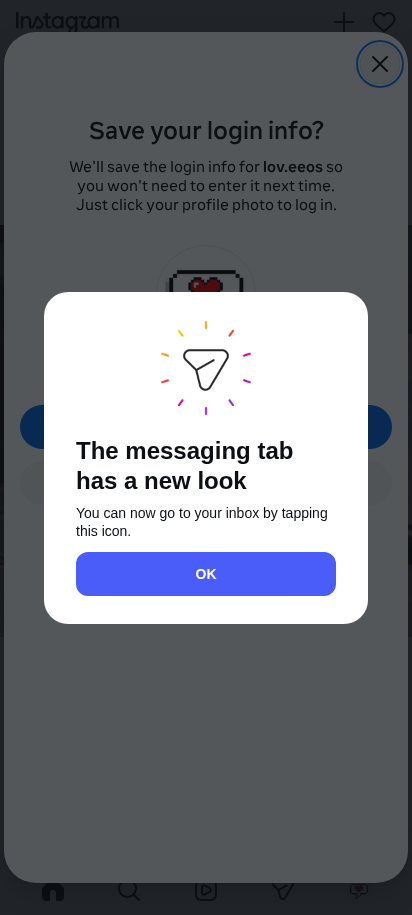

In [7]:
from IPython.display import display, Image as IPImage
import os

os.makedirs(config.data_dir, exist_ok=True)
debug_path = str(config.data_dir / 'debug_feed.png')

await session.page.screenshot(path=debug_path, full_page=False)
print('If you see your Instagram feed = auth works.')
print('If you see "Open Instagram" or login = cookies expired.')
display(IPImage(filename=debug_path, width=412))

## 6c. Test story discovery

In [8]:
discovered = await instagram_nav.get_stories_tray()
print(f'Found {len(discovered)} stories:')
for s in discovered:
    print(f"  @{s['username']} (index={s['index']})")

if not discovered:
    print('\n\u26a0\ufe0f No stories found.')
    print('Check the screenshot in cell 6b.')

[INFO] 2026-09-05 16:20:34 | storyzop.src.browser.instagram | Extracting stories from tray...
INFO:storyzop.src.browser.instagram:Extracting stories from tray...
[INFO] 2026-09-05 16:20:36 | storyzop.src.browser.instagram | Strategy 2 (structural): Found 6 stories.
INFO:storyzop.src.browser.instagram:Strategy 2 (structural): Found 6 stories.


Found 6 stories:
  @Plus iconYour story (index=0)
  @narendramodi (index=1)
  @randomsena (index=2)
  @nsitharaman (index=3)
  @yogiadityanath.bharat (index=4)
  @ddnews_official (index=5)


## 7. Run the Full Pipeline

In [9]:
from src.pipeline import StoryPipeline

pipeline = StoryPipeline(config, db)
pipeline.set_browser(session)
pipeline.set_navigators(instagram_nav, story_nav)
pipeline.set_sampler(sampler, frame_manager)
pipeline.set_models(screener, analyzer, expert)
pipeline.set_ocr(ocr_engine)

print('Starting pipeline...\n')
stats = await pipeline.run()

print(f'\n--- Pipeline Complete ---')
print(f'  Discovered: {stats["discovered"]}')
print(f'  Completed:  {stats["completed"]}')
print(f'  Revisited:  {stats["revisited"]}')
print(f'  Failed:     {stats["failed"]}')

[INFO] 2026-09-05 16:20:36 | storyzop.src.pipeline | Pipeline starting. Resume state: 0 completed, 0 pending, 0 incomplete.
INFO:storyzop.src.pipeline:Pipeline starting. Resume state: 0 completed, 0 pending, 0 incomplete.
[INFO] 2026-09-05 16:20:36 | storyzop.src.pipeline | Discovering stories from tray...
INFO:storyzop.src.pipeline:Discovering stories from tray...
[INFO] 2026-09-05 16:20:36 | storyzop.src.browser.instagram | Extracting stories from tray...
INFO:storyzop.src.browser.instagram:Extracting stories from tray...


Starting pipeline...



[INFO] 2026-09-05 16:20:38 | storyzop.src.browser.instagram | Strategy 2 (structural): Found 6 stories.
INFO:storyzop.src.browser.instagram:Strategy 2 (structural): Found 6 stories.
[INFO] 2026-09-05 16:20:38 | storyzop.src.pipeline | Discovered 6 stories.
INFO:storyzop.src.pipeline:Discovered 6 stories.
[INFO] 2026-09-05 16:20:38 | storyzop.src.pipeline | Processing Story 1/6 (@Plus iconYour story)...
INFO:storyzop.src.pipeline:Processing Story 1/6 (@Plus iconYour story)...
[INFO] 2026-09-05 16:20:38 | storyzop.database | Created person P_000001 ← @Plus iconYour story
INFO:storyzop.database:Created person P_000001 ← @Plus iconYour story
[ERROR] 2026-09-05 16:20:38 | storyzop.src.pipeline | Error processing story 1: Object of type ElementHandle is not JSON serializable
Traceback (most recent call last):
  File "/content/StoryZop/src/pipeline.py", line 148, in run
    story = self.db.create_story(
        person_id=person.person_id,
    ...<2 lines>...
        story_position=item.get("p


--- Pipeline Complete ---
  Discovered: 6
  Completed:  0
  Revisited:  0
  Failed:     6


## 8. View Results

In [10]:
from src.analysis.report import ReportGenerator

report_gen = ReportGenerator(db)
report = report_gen.generate_text_report()
if report:
    print(report)
else:
    print('No stories analyzed yet.')

No stories analyzed yet.


## 9. Export Data

In [11]:
import os
os.makedirs(config.data_dir, exist_ok=True)

json_path = config.data_dir / 'export.json'
csv_path = config.data_dir / 'export.csv'

report_gen.export_json(json_path)
report_gen.export_csv(csv_path)

print(f'\u2705 JSON exported to {json_path}')
print(f'\u2705 CSV exported to {csv_path}')

try:
    from google.colab import files
    files.download(str(json_path))
    files.download(str(csv_path))
except ImportError:
    pass

[INFO] 2026-09-05 16:23:38 | storyzop.src.analysis.report | Exported JSON report to /content/StoryZop/data/export.json
INFO:storyzop.src.analysis.report:Exported JSON report to /content/StoryZop/data/export.json
[INFO] 2026-09-05 16:23:38 | storyzop.src.analysis.report | Exported CSV report to /content/StoryZop/data/export.csv
INFO:storyzop.src.analysis.report:Exported CSV report to /content/StoryZop/data/export.csv


✅ JSON exported to /content/StoryZop/data/export.json
✅ CSV exported to /content/StoryZop/data/export.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Cleanup

In [12]:
await session.close()
print('\u2705 Browser closed.')

if screener.is_loaded:
    screener.unload_model()
if analyzer.is_loaded:
    analyzer.unload_model()
if expert and expert.is_loaded:
    expert.unload_model()
print('\u2705 Models unloaded.')

db.close()
print('\u2705 Database closed.')

[INFO] 2026-09-05 16:23:38 | storyzop.src.browser.session | Closing browser session...
INFO:storyzop.src.browser.session:Closing browser session...


✅ Browser closed.
✅ Models unloaded.
✅ Database closed.
